In [11]:
import h5py
from matplotlib import pyplot as plt

network_types = ["toroidal-lattice", "small-world", "random"]  # Replace with your network type
state_medians = []
state_q1s = []
state_q3s = []
defect_medians = []
defect_q1s = []
defect_q3s = []

for network_type in network_types:
    # Open the .h5 file in read mode
    file_path = f"results_{network_type}.h5"  # Replace with your file name
    with h5py.File(file_path, "r") as f:
        # Navigate to the group path
        resolution = 5  # Replace with your resolution
        group_path = f"resolution{resolution}/{network_type}"
        
        # Check if the group exists
        if group_path in f:
            # Access datasets
            state_median = f[f"{group_path}/state/median"][:]
            state_q1 = f[f"{group_path}/state/q1"][:]
            state_q3 = f[f"{group_path}/state/q3"][:]
            defect_median = f[f"{group_path}/defect/median"][:]
            defect_q1 = f[f"{group_path}/defect/q1"][:]
            defect_q3 = f[f"{group_path}/defect/q3"][:]
            
            # Append data to lists
            state_medians.append(state_median)
            state_q1s.append(state_q1)
            state_q3s.append(state_q3)
            defect_medians.append(defect_median)
            defect_q1s.append(defect_q1)
            defect_q3s.append(defect_q3)
        else:
            print(f"Group {group_path} does not exist in the file.")

## Compare state and defect values per network type

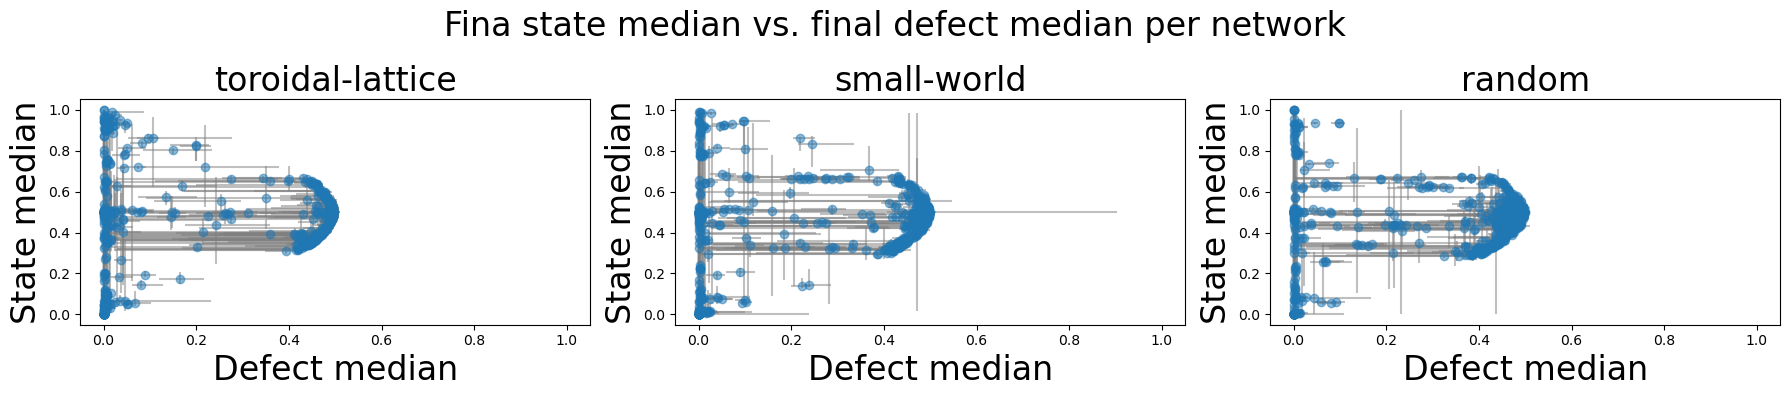

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
fontsize=24

for idx in range(3):
    defect_median = defect_medians[idx]
    defect_q1 = defect_q1s[idx]
    defect_q3 = defect_q3s[idx]
    state_median = state_medians[idx]
    state_q1 = state_q1s[idx]
    state_q3 = state_q3s[idx]
    axs[idx].errorbar(defect_median,
                      state_median,
                      xerr=[defect_median - defect_q1, defect_q3 - defect_median],
                      yerr=[state_median - state_q1, state_q3 - state_median],
                      fmt='o',
                      ecolor='grey',
                      alpha=0.5)
    axs[idx].set_title(f"{network_types[idx]}", fontsize=fontsize)
    axs[idx].set_xlabel("Defect median", fontsize=fontsize)
    axs[idx].set_ylabel("State median", fontsize=fontsize)
    axs[idx].set_xlim(-0.05, 1.05)
    axs[idx].set_ylim(-0.05, 1.05)
fig.suptitle("Final state median vs. final defect median per network", fontsize=fontsize)
plt.tight_layout()
plt.show()

## Compare state medians across network types

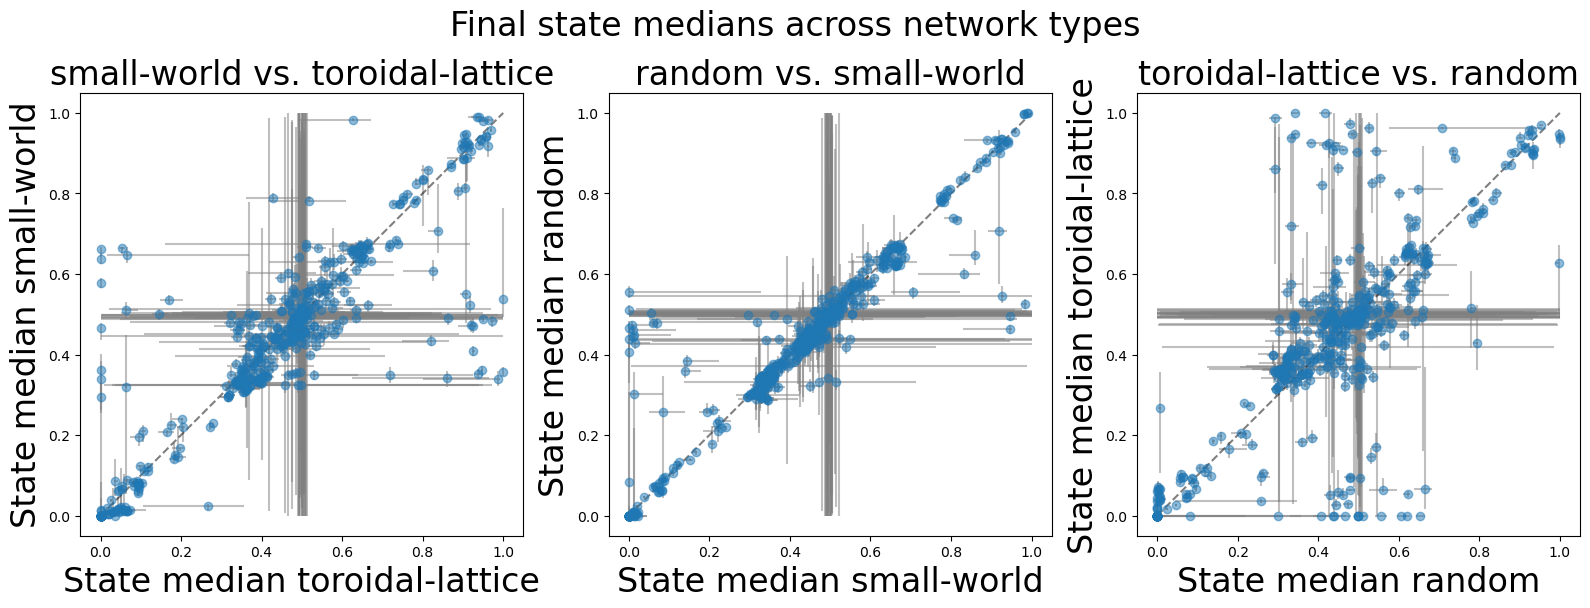

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))

for idx in range(3):
    state_median_x = state_medians[idx]
    state_median_y = state_medians[(idx+1)%3]
    state_q1_x = state_q1s[idx]
    state_q1_y = state_q1s[(idx+1)%3]
    state_q3_x = state_q3s[idx]
    state_q3_y = state_q3s[(idx+1)%3]
    axs[idx].errorbar(state_median_x,
                      state_median_y,
                      xerr=[state_median_x - state_q1_x, state_q3_x - state_median_x],
                      yerr=[state_median_y - state_q1_y, state_q3_y - state_median_y],
                      fmt='o',
                      ecolor='grey',
                      alpha=0.5)
    axs[idx].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axs[idx].set_title(f"{network_types[(idx+1)%3]} vs. {network_types[idx]}", fontsize=fontsize)
    axs[idx].set_xlabel(f"State median {network_types[idx]}", fontsize=fontsize)
    axs[idx].set_ylabel(f"State median {network_types[(idx+1)%3]}", fontsize=fontsize)
    axs[idx].set_xlim(-0.05, 1.05)
    axs[idx].set_ylim(-0.05, 1.05)
    axs[idx].set_aspect(1)
fig.suptitle("Final state medians across network types", fontsize=fontsize)
fig.tight_layout()

## Compare defect medians across network types

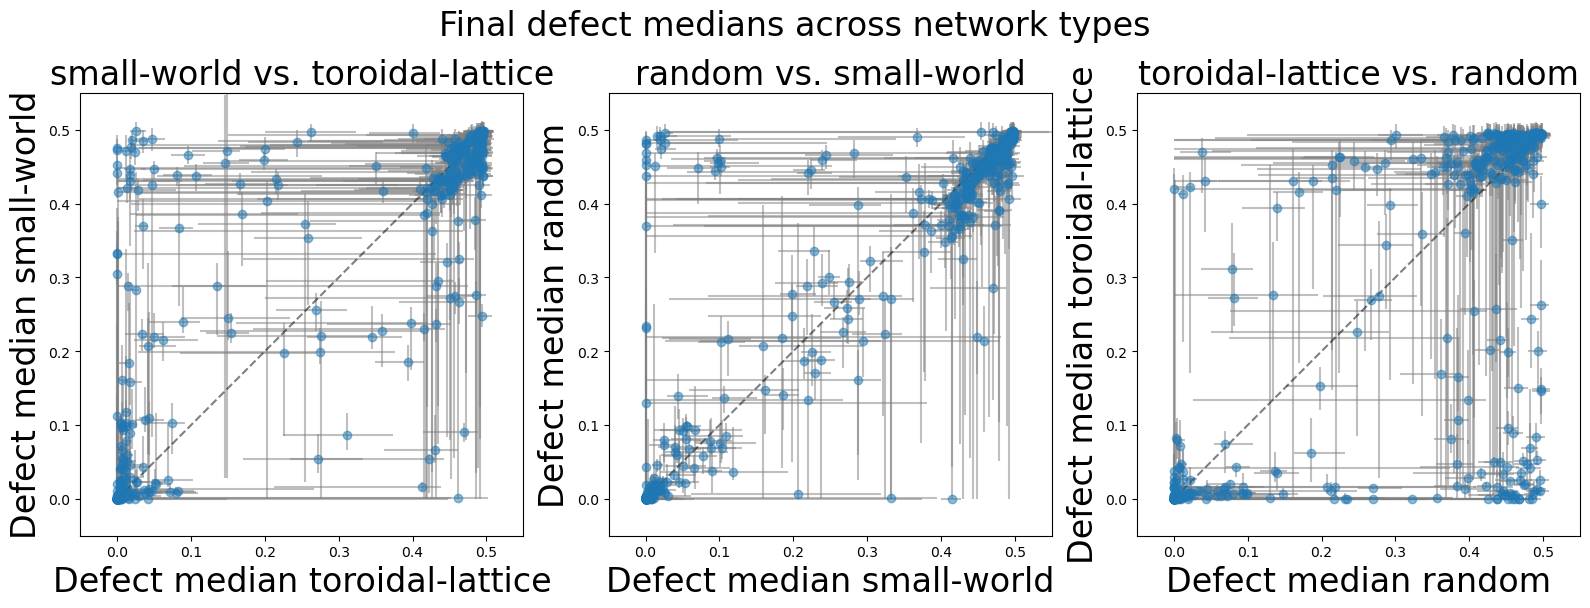

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(16, 6))

for idx in range(3):
    defect_median_x = defect_medians[idx]
    defect_median_y = defect_medians[(idx+1)%3]
    defect_q1_x = defect_q1s[idx]
    defect_q1_y = defect_q1s[(idx+1)%3]
    defect_q3_x = defect_q3s[idx]
    defect_q3_y = defect_q3s[(idx+1)%3]
    axs[idx].errorbar(defect_median_x,
                      defect_median_y,
                      xerr=[defect_median_x - defect_q1_x, defect_q3_x - defect_median_x],
                      yerr=[defect_median_y - defect_q1_y, defect_q3_y - defect_median_y],
                      fmt='o',
                      ecolor='grey',
                      alpha=0.5)
    axs[idx].plot([0, .5], [0, .5], 'k--', alpha=0.5)
    axs[idx].set_title(f"{network_types[(idx+1)%3]} vs. {network_types[idx]}", fontsize=fontsize)
    axs[idx].set_xlabel(f"Defect median {network_types[idx]}", fontsize=fontsize)
    axs[idx].set_ylabel(f"Defect median {network_types[(idx+1)%3]}", fontsize=fontsize)
    axs[idx].set_xlim(-0.05, 0.55)
    axs[idx].set_ylim(-0.05, 0.55)
    axs[idx].set_aspect(1)
fig.suptitle("Final defect medians across network types", fontsize=fontsize)
fig.tight_layout()